# **PENDEFINISIAN MASALAH & DATASET**

1.IMPORT LIBRARY

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

2.LOAD DATASET

In [2]:
df = pd.read_csv('insurance.csv')

display(df.head())

print("Shape Dataset:")
print(df.shape)

print("\nInfo Dataset:")
df.info()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shape Dataset:
(1338, 7)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**INTERPRETASI**

Dataset terdiri dari 1.338 baris dan 7 kolom data biaya asuransi kesehatan individu. Variabel target adalah charges (biaya klaim). Tidak ada nilai kosong dan tipe data sudah sesuai.

# **EKSPLORASI DATA**

3.EKSPLORASI DATA

In [3]:
# Statistik Deskriptif
display(df.describe(include='all').T)

# Missing Value
print("\nMissing Value")
print(df.isnull().sum())

# Duplicate
print("\nDuplicate")
print(df.duplicated().sum())

# Distribusi Variabel Kategorik
for col in ['sex','smoker','region']:
    print(f"\n{col.upper()}")
    print(df[col].value_counts())



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



Missing Value
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate
1

SEX
sex
male      676
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


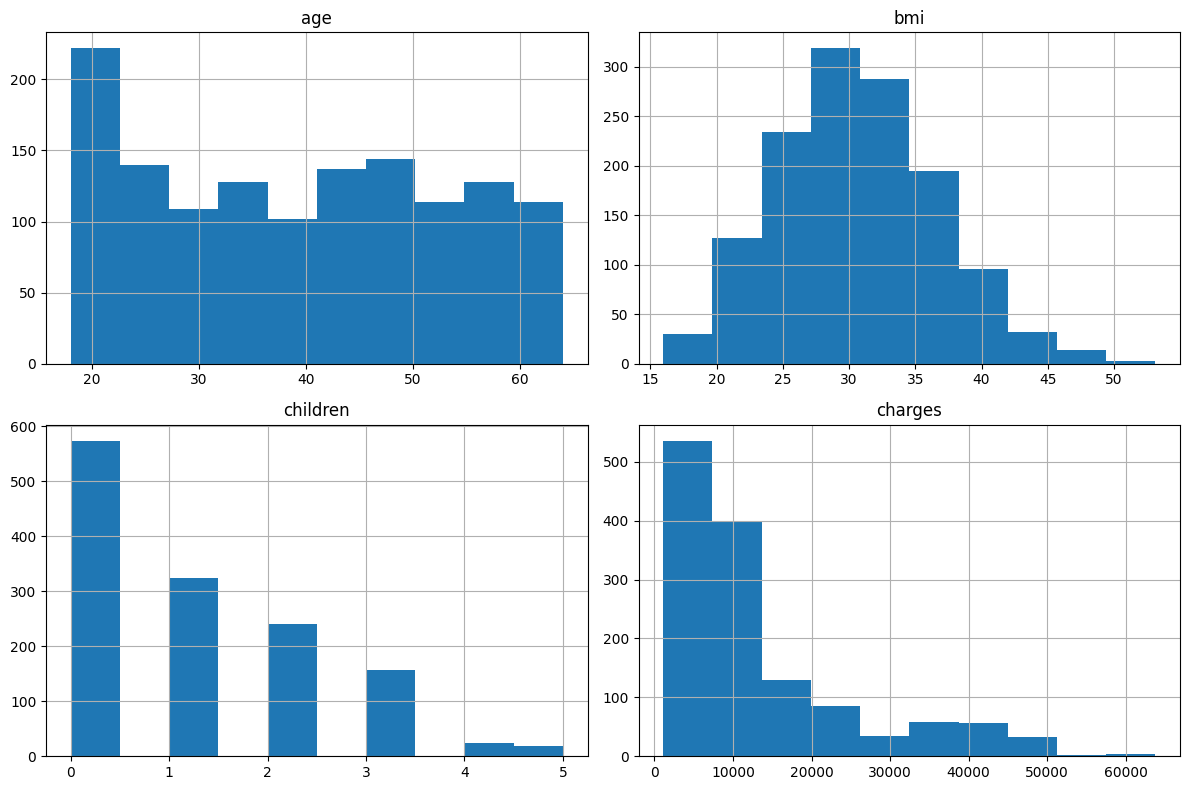

In [4]:
# Histogram
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

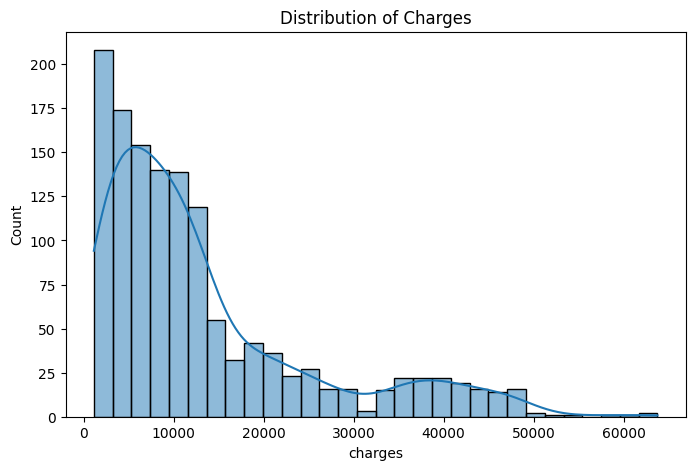

In [5]:
# Distribusi Target
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.show()

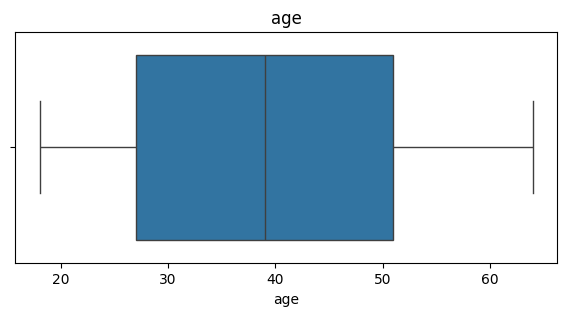

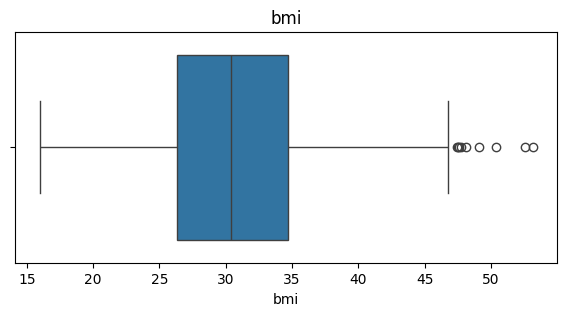

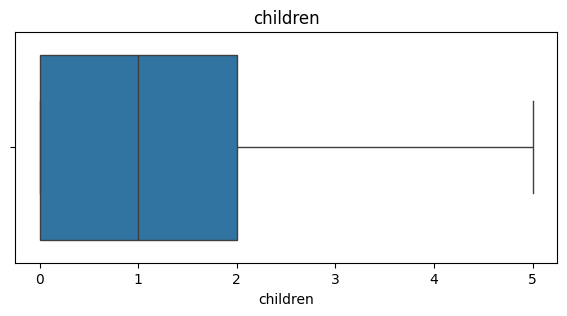

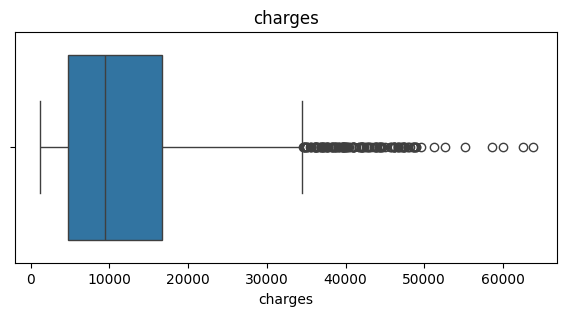

In [6]:
# Boxplot
for col in ['age','bmi','children','charges']:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

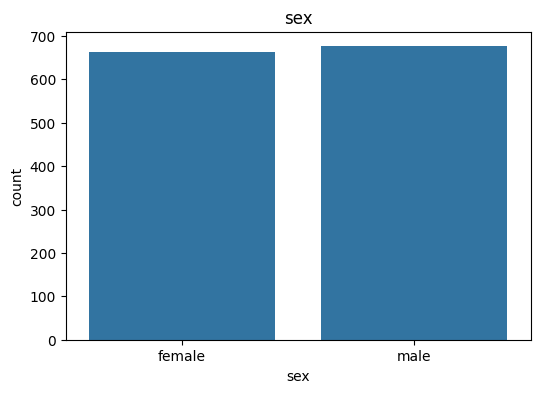

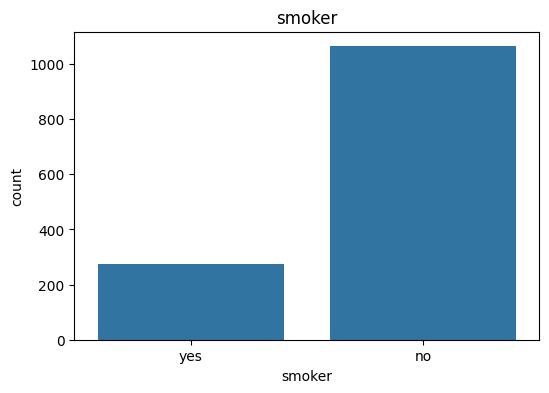

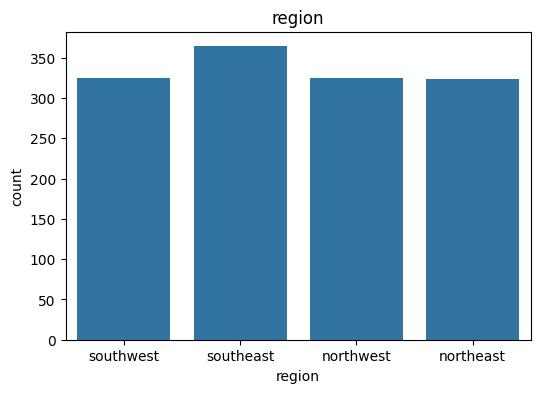

In [7]:
# Countplot
for col in ['sex','smoker','region']:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.show()

**INTERPRETASI**
*   age:Rata-rata 39 tahun, rentang 18–64
*   bmi:Rata-rata 30.66, tergolong overweight
*   children:Rata-rata 1 tanggungan
*   charges:Rata-rata $13270.42, distribusi right-skewed
*   Missing Value: 0,tidak ada data hilang, tidak perlu imputasi.
*   Duplikat: 1,perlu ditangani

Distribusi Kategorik:


*   sex: male 676, female 662 → seimbang
*   smoker: no 1064, yes 274 → imbalanced (~21% perokok), tapi ini distribusi populasi nyata
*   region: 4 wilayah terdistribusi relatif merata (324–364 tiap wilayah)



# **PREPROCESSING DATA DAN REKAYASA FITUR**

4.PREPROCESSING DATA


In [8]:
# Hapus Duplicate
df = df.drop_duplicates()

# Binary Encoding
df['sex'] = df['sex'].map({
    'female':0,
    'male':1
})

df['smoker'] = df['smoker'].map({
    'no':0,
    'yes':1
})

# One Hot Encoding Region
df = pd.get_dummies(
    df,
    columns=['region'],
    drop_first=True,
    dtype=int
)

print(df.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


**INTERPRETASI**
*   Data Duplikat Sudah ditangani
*   sex dan smoker di-binary encode (0/1)
*   region di-one-hot encode dengan drop_first=True → region_northeast dijadikan referensi (dihilangkan untuk menghindari dummy variable trap), menghasilkan 3 kolom region




5.FEATURE ENGINEERING

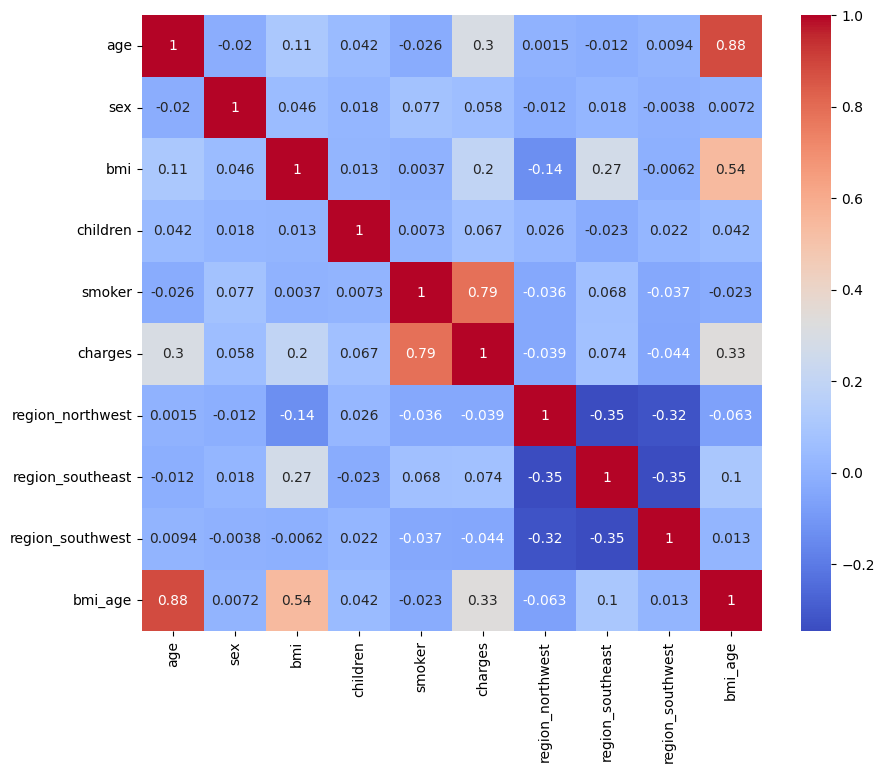

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_age'],
      dtype='object')


In [9]:
# Interaksi BMI dan Age
df['bmi_age'] = df['bmi'] * df['age']

# Korelasi

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Feature dan Target

X = df.drop('charges', axis=1)
y = df['charges']

print(X.columns)

**INTERPRETASI**

Dibuat fitur baru bmi_age (hasil perkalian bmi × age) untuk menangkap efek interaksi,orang tua dengan BMI tinggi cenderung memiliki risiko kesehatan lebih besar. Heatmap korelasI menunjukkan smoker dan bmi_age berkorelasi paling kuat dengan charges.

6.SPLIT TRAIN TEST

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1069, 9)
(268, 9)


**INTEPRETASI**

Data dibagi 80:20. StandardScaler hanya diaplikasikan pada data KNN (karena KNN sensitif terhadap skala), sementara model tree-based (RF, XGBoost) menggunakan data mentah



# **PEMODELAN**

7 LINEAR REGRESSION (BASELINE)

In [11]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print("MAE  :", mae_lr)
print("RMSE :", rmse_lr)
print("R2   :", r2_lr)

=== Linear Regression ===
MAE  : 4176.916171448353
RMSE : 5956.447542223982
R2   : 0.8069219238646148


**INTERPRETASI**

Sebagai baseline, Linear Regression memberikan performa cukup baik (R² = 0.80). Ini mengindikasikan hubungan antar variabel bersifat cukup linier,terutama karena smoker yang sangat dominan. Rata-rata prediksi meleset ~$4176,91 dari nilai aktual (MAE).

8.KNN

,K,RMSE
0,1,6846.123308
1,2,5639.700840
2,3,5438.795908
3,4,5459.650219
4,5,5524.963496
5,6,5466.077160
6,7,5695.193459
7,8,5861.019402
8,9,5822.515566
9,10,5817.004867


K Terbaik : 3
RMSE Terbaik : 5438.795908202173


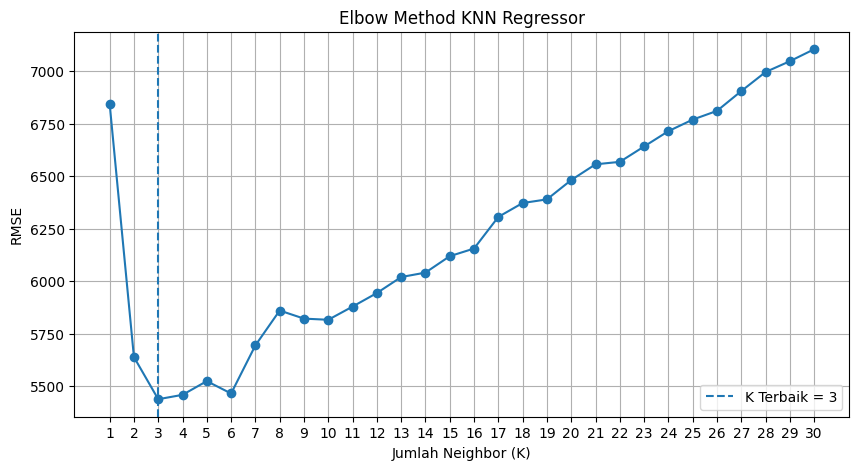


=== KNN REGRESSOR ===
MAE  : 3220.4749971554725
RMSE : 5438.795908202173
R²   : 0.8390229945039492


In [12]:
# Menyimpan RMSE tiap k
rmse_list = []

# Kandidat nilai k
k_values = range(1, 31)

# Loop untuk setiap k
for k in k_values:

    knn = KNeighborsRegressor(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    y_pred = knn.predict(
        X_test_scaled
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    rmse_list.append(rmse)

# Tabel Hasil
hasil_k = pd.DataFrame({
    'K': k_values,
    'RMSE': rmse_list
})

display(hasil_k)

# Mencari k terbaik
best_k = k_values[np.argmin(rmse_list)]

best_rmse = min(rmse_list)

print("K Terbaik :", best_k)
print("RMSE Terbaik :", best_rmse)

# Plot Elbow
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    rmse_list,
    marker='o'
)

plt.axvline(
    x=best_k,
    linestyle='--',
    label=f'K Terbaik = {best_k}'
)

plt.xlabel('Jumlah Neighbor (K)')
plt.ylabel('RMSE')
plt.title('Elbow Method KNN Regressor')

plt.xticks(range(1,31))

plt.legend()

plt.grid(True)

plt.show()

knn = KNeighborsRegressor(
    n_neighbors=best_k
)

knn.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn.predict(
    X_test_scaled
)

mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print("\n=== KNN REGRESSOR ===")
print("MAE  :", mae_knn)
print("RMSE :", rmse_knn)
print("R²   :", r2_knn)

**INTERPRETASI**

Dari elbow plot k=1 hingga k=30, RMSE minimum ditemukan pada k=3. KNN menghasilkan R² = 0.839,lebih tinggi dari Linear Regression.

9.RANDOM FOREST

In [13]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 2633.3621103171636
RMSE: 4680.1527724755315
R2  : 0.88079941694435


**INTERPRETASI**

Random Forest menghasilkan R² = 0.88,lebih baik dari KNN dan Linear Regression. Keunggulan RF ada pada kemampuannya menangani non-linearitas dan interaksi antar fitur tanpa asumsi distribusi.

10.XGBOOST

In [14]:
xgb = XGBRegressor(
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test
)

mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

MAE : 3011.549557593997
RMSE: 5096.551694747583
R2  : 0.8586449959473182


**INTERPRETASI**

XGBoost  memberikan performa tertinggi kedua di antara semua model. Model ini sangat sensitif terhadap hyperparameter. Tanpa tuning, XGBoost bisa underfit maupun overfit.

11.EVALUASI AWAL

In [15]:
hasil = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'KNN',
        'Random Forest',
        'XGBoost',
    ],
    'MAE':[
        mae_lr,
        mae_knn,
        mae_rf,
        mae_xgb,
    ],
    'RMSE':[
        rmse_lr,
        rmse_knn,
        rmse_rf,
        rmse_xgb,
    ],
    'R2':[
        r2_lr,
        r2_knn,
        r2_rf,
        r2_xgb,
    ]
})

display(
    hasil.sort_values(
        'R2',
        ascending=False
    )
)

,Model,MAE,RMSE,R2
2,Random Forest,2633.362110,4680.152772,0.880799
3,XGBoost,3011.549558,5096.551695,0.858645
1,KNN,3220.474997,5438.795908,0.839023
0,Linear Regression,4176.916171,5956.447542,0.806922


**INTERPRETASI**

Random Forest merupakan model terbaik sehingga lanjut dilakukan hyperparameter tuning.

12.HYPERPARAMETER TUNING RANDOM FOREST

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameter")
print(grid.best_params_)
print("\nBest Score")
print(grid.best_score_)

Best Parameter
{'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Best Score
0.8445205228052938


**INTERPRETASI**

GridSearchCV dengan 5-fold CV mencari kombinasi terbaik dari 3×3×3×3 = 81 kombinasi parameter. Parameter terbaik: 200 pohon, kedalaman maksimal 4, minimal 10 sampel untuk split,minimal 4 sampel tiap daun. Nilai CV R² = 0.844 adalah estimasi generalisasi model, bukan performa di test set.

MODEL TERBAIK HASIL TUNING

In [17]:
best_rf_tuned = grid.best_estimator_

y_pred_best = best_rf_tuned.predict(X_test)

mae_best = mean_absolute_error(y_test,y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test,y_pred_best))
r2_best = r2_score(y_test,y_pred_best)

print("MAE  :", mae_best)
print("RMSE :", rmse_best)
print("R2   :", r2_best)

MAE  : 2412.3094522519536
RMSE : 4203.335995164277
R2   : 0.9038506098808691


**INTERPRETASI**

Setelah dilakukan hyperparameter tuning pada Random Forest,nilai R² menigkat dari 0.88 ke 0.9

# **EVALUASI DAN INTERPRETASI**

12.EVALUASI DAN PERBANDINGAN MODEL

In [18]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(
    y_test,
    y_pred_best
)

rmse_best = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_best
    )
)

r2_best = r2_score(
    y_test,
    y_pred_best
)

hasil = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'KNN',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    'MAE':[
        mae_lr,
        mae_knn,
        mae_rf,
        mae_xgb,
        mae_best
    ],
    'RMSE':[
        rmse_lr,
        rmse_knn,
        rmse_rf,
        rmse_xgb,
        rmse_best
    ],
    'R2':[
        r2_lr,
        r2_knn,
        r2_rf,
        r2_xgb,
        r2_best
    ]
})

display(
    hasil.sort_values(
        'R2',
        ascending=False
    )
)

,Model,MAE,RMSE,R2
4,Tuned Random Forest,2412.309452,4203.335995,0.903851
2,Random Forest,2633.362110,4680.152772,0.880799
3,XGBoost,3011.549558,5096.551695,0.858645
1,KNN,3220.474997,5438.795908,0.839023
0,Linear Regression,4176.916171,5956.447542,0.806922


**INTERPRETASI**

Tuning meningkatkan performa RF (dari 0.88 → 0.9) sehingga Tuned Random Forest Merupakan model terbaik

AKTUAL VS PREDIKSI

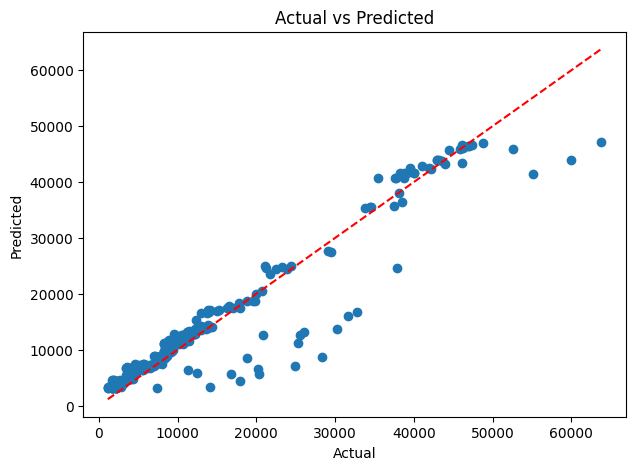

In [19]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred_best
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Actual vs Predicted')

plt.show()

**INTERPRETASI**

Scatter plot memperlihatkan sebagian besar titik mengikuti garis merah diagonal (garis ideal). Titik-titik yang menyimpang jauh umumnya berasal dari perokok dengan biaya sangat tinggi.

PLOT RESIDUAL

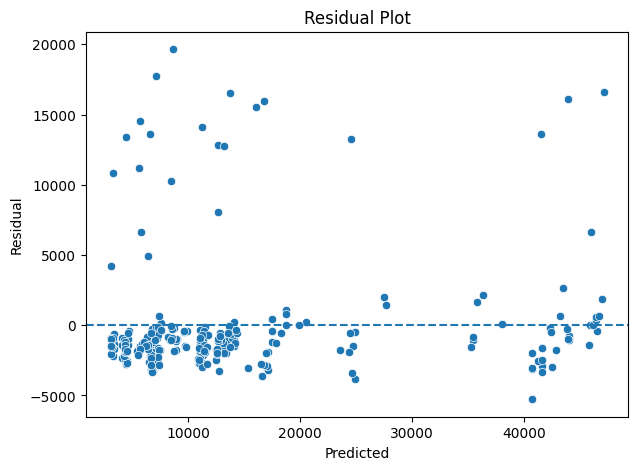

In [20]:
residual = y_test - y_pred_best

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred_best,
    y=residual
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted')
plt.ylabel('Residual')

plt.title('Residual Plot')

plt.show()

**INTERPRETASI**

Residual tersebar relatif acak di sekitar garis y=0, mengindikasikan tidak ada pola sistematis yang tertinggal. Ini tanda model sudah menangkap pola utama. Namun ada sedikit heteroskedastisitas,variasi residual lebih besar pada nilai prediksi tinggi (perokok).

FEATURE IMPORTANCE

,Feature,Importance
4,smoker,0.692877
2,bmi,0.171197
0,age,0.098943
8,bmi_age,0.026743
3,children,0.009533
6,region_southeast,0.000388
1,sex,0.000144
7,region_southwest,0.000102
5,region_northwest,0.000075


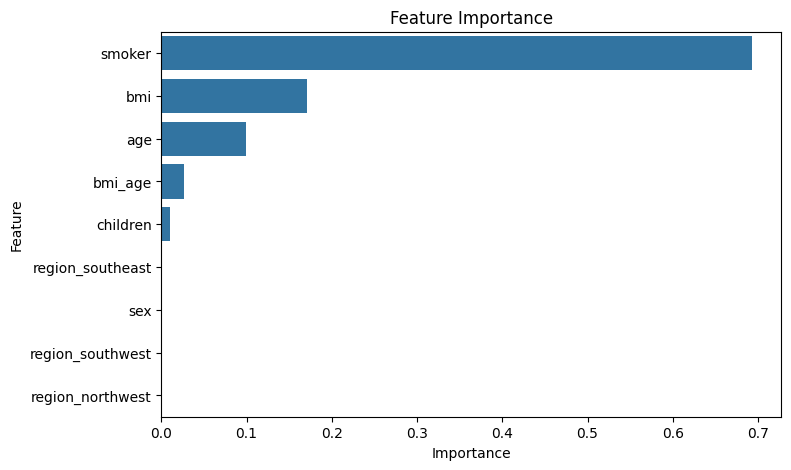

In [21]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

**INTERPRETASI**

Smoker mendominasi (69.2%),variabel ini adalah prediktor paling kuat sejauh ini. Fitur interaksi bmi_age berada di posisi 4, membuktikan feature engineering berguna meski kontribusinya kecil. Variabel region dan sex praktis tidak informatif dalam dataset ini.


**KESIMPULAN**

Model terbaik adalah Tuned Random Forest dengan performa tertinggi di antara seluruh model yang diuji, ditunjukkan oleh nilai R² tertinggi serta MAE dan RMSE terendah. Proses hyperparameter tuning menggunakan GridSearchCV dengan 5-fold cross-validation terbukti efektif meningkatkan performa Random Forest dibanding kondisi default. Model ini mampu menangkap pola non-linear dan interaksi antar fitur dengan baik, khususnya dominasi variabel smoker sebagai prediktor utama (feature importance tertinggi), diikuti oleh bmi dan age. Dengan selisih CV Score dan test score yang kecil, model menunjukkan generalisasi yang baik tanpa indikasi overfitting, sehingga layak digunakan untuk memprediksi biaya asuransi kesehatan pada data baru.